In [44]:

from pathlib import Path

from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from chemprop.featurizers.atom import MultiHotAtomFeaturizer
from rdkit.Chem.rdchem import HybridizationType
import pandas as pd
from rdkit import Chem
from chemprop import data, featurizers, models, nn
from ml_enhance import QuantumFPFileLoader

In [33]:
loader = QuantumFPFileLoader("data/QuantumFP/QFP_output")
filelist = loader.list_output_files()
for df in loader.stream_conformer_dataframe(filelist[0]):
    tdf = df

In [42]:
tdf["original_smiles"].values

<StringArray>
['[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23']
Length: 1, dtype: string

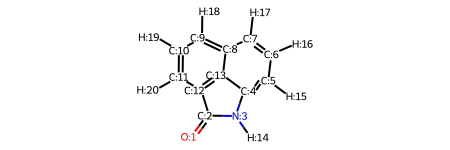

In [62]:
Chem.MolFromSmiles('[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23', sanitize=False)

In [63]:
for atom in Chem.MolFromSmiles('[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c:6]([H:16])[c:7]([H:17])[c:8]3[c:9]([H:18])[c:10]([H:19])[c:11]([H:20])[c:12]1[c:13]23', sanitize=False).GetAtoms():
    print(atom.GetAtomMapNum())

1
2
3
14
4
5
15
6
16
7
17
8
9
18
10
19
11
20
12
13


In [39]:
tdf["partial_charge"].values

array([list([[1, 0.40345778309363234], [2, -0.2764986552283286], [3, 0.16109831127126406], [4, -0.06636472073527822], [5, 0.05043119541237995], [6, 0.02795168179286378], [7, 0.042122813461209274], [8, -0.018430841478360938], [9, 0.026276892566730048], [10, 0.02803153455022067], [11, 0.012169930887049984], [12, 0.02418403162335636], [13, 0.01720197466482687], [14, -0.17607179995862898], [15, -0.037231695404674636], [16, -0.04045699148472259], [17, -0.038477327303914066], [18, -0.042513819271061015], [19, -0.043088833291279105], [20, -0.053791465167273955]])],
      dtype=object)

In [36]:
tdf["atomic_dipole_norm"].to_numpy()

array([list([[1, 0.18897060020049597], [2, 0.07975410315046821], [3, 0.028972509046823657], [4, 0.1762767955839678], [5, 0.015332401923735998], [6, 0.04752877648022439], [7, 0.039801136886359174], [8, 0.01147875665814521], [9, 0.031104628636960785], [10, 0.04041787914473369], [11, 0.02378763909249575], [12, 0.07815241155848879], [13, 0.02313575457981608], [14, 0.15182256251538848], [15, 0.15237882064686034], [16, 0.14534213473662566], [17, 0.14957361946362363], [18, 0.14896644200131212], [19, 0.14622914583232913], [20, 0.153725001868534]])],
      dtype=object)

In [8]:
df = pd.read_csv(r"data\processed_dataset.csv")[:100]

In [27]:
df.filter(regex="bond")

,avg_bond_stiffness,avg_bond_length,avg_bond_energy,num_heavy_H_bonds,fr_phenol_noOrthoHbond
0,0.937594,2.430785,0.211958,7.000000,0
1,0.893948,2.449879,0.209662,5.000000,0
2,0.769180,2.365002,0.210992,18.000000,0
3,0.815349,2.376840,0.201753,11.000022,0
4,0.901513,2.465851,0.212419,10.000000,0
...,...,...,...,...,...
95,0.677538,3.029258,0.000000,0.000000,0
96,0.767838,2.352347,0.206542,32.000000,0
97,0.883770,2.391366,0.207787,15.000000,2
98,0.907652,2.425250,0.210019,13.000049,0


In [3]:
all_data = [data.MoleculeDatapoint.from_smi(smi, sol, keep_h=True) for _, (smi, sol) in df[["smiles", "solubility"]].iterrows()]

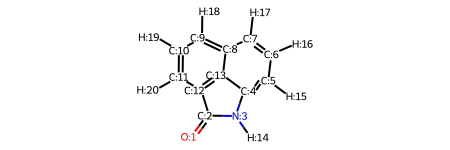

In [60]:
all_data[0].mol

In [58]:
for atom in all_data[0].mol.GetAtoms():
    print(atom.GetAtomMapNum())

1
2
3
14
4
5
15
6
16
7
17
8
9
18
10
19
11
20
12
13


In [ ]:
atomic_nums = list(range(1, 37)) + [53] # Look up which atomic numbers occur in the dataset
degrees = [0, 1, 2, 3, 4, 5]
formal_charges = []
chiral_tags = [0, 1, 2, 3]
num_Hs = [0, 1, 2, 3, 4]
hybridizations = [HybridizationType.S, HybridizationType.SP, HybridizationType.SP2, HybridizationType.SP2D, HybridizationType.SP3, HybridizationType.SP3D, HybridizationType.SP3D2]
featurizer = MultiHotAtomFeaturizer(
    atomic_nums, degrees, formal_charges, chiral_tags, num_Hs, hybridizations
)
featurizer(atom_to_featurize)

array([0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       1.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.     , 1.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 1.     , 1.     , 0.     , 0.     ,
       0.     , 0.     , 1.     , 0.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 1.     , 0.     , 0.     , 0.     ,
       0.     , 0.     , 0.     , 0.15999])

In [45]:
mols = [d.mol for d in all_data]  # RDkit Mol objects are use for structure based splits

train_indices, val_indices, test_indices = data.make_split_indices(mols, "random", (0.8, 0.1, 0.1))  # unpack the tuple into three separate lists
train_data, val_data, test_data = data.split_data_by_indices(
    all_data, train_indices, val_indices, test_indices
)

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)


In [ ]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

train_dset = data.MoleculeDataset(train_data[0], featurizer)

train_dset._X_d

# scaler = train_dset.normalize_targets()

val_dset = data.MoleculeDataset(val_data[0], featurizer)
# val_dset.normalize_targets(scaler)

test_dset = data.MoleculeDataset(test_data[0], featurizer)

In [50]:
num_workers = 1
train_loader = data.build_dataloader(train_dset, num_workers=num_workers)
val_loader = data.build_dataloader(val_dset, num_workers=num_workers, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=num_workers, shuffle=False)

In [55]:
mp = nn.BondMessagePassing()
agg = nn.MeanAggregation()
ffn = nn.RegressionFFN()

batch_norm = True
metric_list = [nn.metrics.RMSE(), nn.metrics.MAE()]

mpnn = models.MPNN(mp, agg, ffn, batch_norm, metric_list)
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=300, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): Identity()
  )
  (X_d_transform): Identity()
  (metrics): ModuleList(
    (0): RMSE(task_weights=[[1.0]])
    (1): MAE(task_weights=[[1.0

In [57]:
# Configure model checkpointing
checkpointing = ModelCheckpoint(
    "checkpoints",  # Directory where model checkpoints will be saved
    "best-{epoch}-{val_loss:.2f}",  # Filename format for checkpoints, including epoch and validation loss
    "val_loss",  # Metric used to select the best checkpoint (based on validation loss)
    mode="min",  # Save the checkpoint with the lowest validation loss (minimization objective)
    save_last=True,  # Always save the most recent checkpoint, even if it's not the best
)


trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=True, # Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=20, # number of epochs to train for
    callbacks=[checkpointing], # Use the configured checkpoint callback
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [58]:
trainer.fit(mpnn, train_loader, val_loader)

Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\rich\live
.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\lightning
\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' 
to speed up the dataloader worker initialization.

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\chemprop\
nn\metrics.py:141: UserWarning: Using a target size (torch.Size([10])) that is different to the input size 
(torch.Size([10, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the 
same size.
  return F.mse_loss(preds, targets, reduction="none")

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\chemprop\
nn\metrics.py:141: UserWarning: Using a target size (torch.Size([64])) that is different to the input size 
(torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the 
same size.
  return F.mse_loss(preds, targets, reduction="none")

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\chemprop\
nn\metrics.py:141: UserWarning: Using a target size (torch.Size([16])) that is different to the input size 
(torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the 
same size.
  return F.mse_loss(preds, targets, reduction="none")

`Trainer.fit` stopped: `max_epochs=20` reached.
